# Taller 5:  Filtros lineales y no lineales

In [1]:
PATH = './imagenes/'

## Cargue la imagen morpho en escala de grises y visualícela.

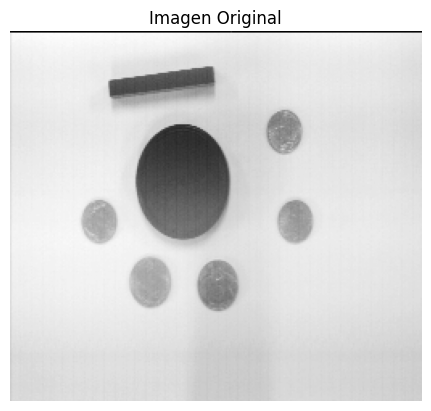

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_morpho = cv2.imread(PATH + 'MORPHO.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen_morpho, cmap='gray')
plt.axis('off')
plt.title('Imagen Original')
plt.show()

## Perturbe (ensucie) la imagen con 25% de ruido “sal y pimienta”. En la imagen ya existen pixeles aberrantes (con intensidades extremas). Esta operación es hecha para amplificar el fenómeno y facilitar la respuesta a la pregunta 9. Nota: El ruido “pimienta y sal” está constituido de picos claros y oscuros (cuyos valores se deben definir en el módulo) con distribución espacial aleatoria. 25 % de pixeles perturbados por este ruido son suficientes para que la imagen morpho.png sea bastante degradada.

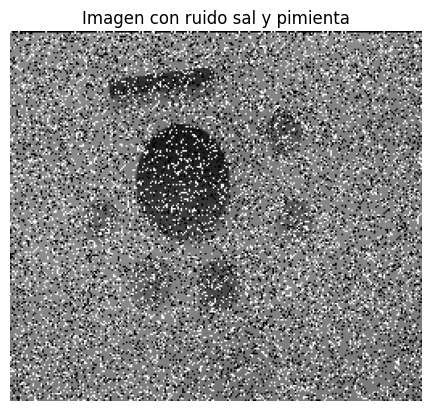

In [7]:
from skimage.util import random_noise
noised_image_morpho = random_noise(imagen_morpho, mode='s&p', amount=0.25)
plt.imshow(noised_image_morpho, cmap='gray')
plt.axis('off')
plt.title('Imagen con ruido sal y pimienta')
plt.show()

## Aplique un filtro promedio 3x3 sobre la imagen con ruido. Visualmente, ¿cómo es el resultado y a qué se debe?

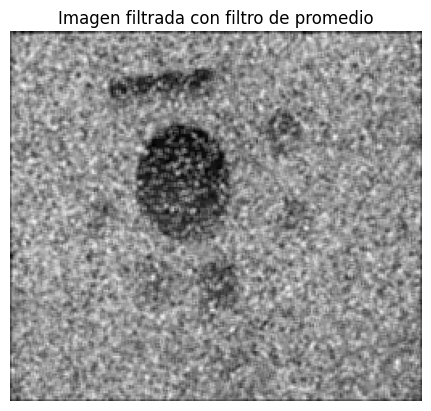

In [9]:
from scipy.ndimage import convolve
import numpy as np

kernel = np.array([[1, 1, 1],
                   [1, 1, 1],
                   [1, 1, 1]])

imagen_filtro_promedio_morpho_syp = convolve(noised_image_morpho, kernel, mode='constant', cval=0)
plt.imshow(imagen_filtro_promedio_morpho_syp, cmap='gray')
plt.axis('off')
plt.title('Imagen filtrada con filtro de promedio')
plt.show()


El resultado es que la imagen visualmente queda peor después del filtro. Esto se debe a que el filtro promedio no funciona bien en ruido de tipo sal y pimienta, debido a que el promedio no elimina los valores de intesidad de grises extremos que caracterizan a este tipo de ruido. Lo que hace realmente es afectar los píxeles que no habían sido afectados por el ruido, debido a que se promedian con sus vecinos con valores extremos.

## Aplique un filtro sigma 3x3 calculando el valor medio a partir pixel central sobre la imagen con ruido. Visualmente, ¿cómo es el resultado comparado con el filtro promedio lineal? Consultando la definición del Sigma explique este resultado. En el caso del ruido “sal y pimienta”, después de aplicar el filtro Sigma, quedan varios puntos aberrantes. ¿A qué se debe esto?

In [11]:
import numpy as np
from scipy.ndimage import generic_filter


def sigma_filter(values, median=False):
    
    mean = values[int((values.size)//2)]
    if median:
      mean = np.median(values)

    std = np.std(values)
    filtered_values = values[(values > mean - std) & (values < mean + std)]
    return np.mean(values) if filtered_values.size<=1 else np.mean(filtered_values)


image_morpho_filtered_sigma = generic_filter(noised_image_morpho, sigma_filter, size=(3,3), extra_arguments=(True,))

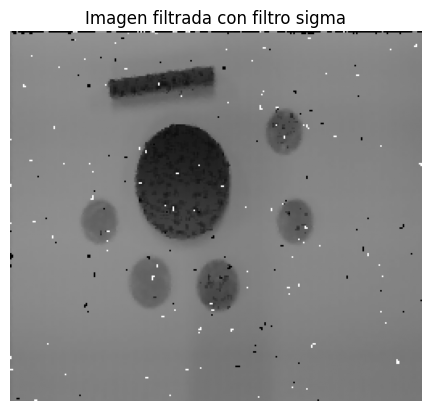

In [12]:
plt.imshow(image_morpho_filtered_sigma, cmap='gray')
plt.axis('off')
plt.title('Imagen filtrada con filtro sigma')
plt.show()

La imagen mejora bastante visualmente respecto al filtro promedio porque, al usar el atributo `median=True`, el rango de promediado se centra en un valor más real de la vecindad y no en un píxel con valor extremo de ruido. Según la lógica del filtro Sigma, esto permite que se promedien solo los píxeles que no difieran en más de un Sigma respecto a esa mediana, lo que ayuda a limpiar la imagen sin afectar los píxeles centrales con los valores extremos de sal y pimienta.

Los puntos aberrantes de sal y pimienta siguen apareciendo porque, si un píxel de ruido es muy extremo, puede que sea el único que cumpla el requisito o que ningún vecino esté cerca de la mediana. Cuando esto pasa, el código aplica la excepción y reemplaza el valor con el promedio global de la vecindad. Como ese promedio todavía tiene metidos los valores 0 o 255 del ruido, el punto no desaparece del todo y se queda ahí como una mancha que el filtro no pudo corregir bien.

## Aplique un filtro mediano 3x3 a la imagen con ruido. Visualmente, ¿cómo es el resultado comparado con los dos filtros anteriores? ¿A qué se debe este resultado? Evalúe los otros filtros que ofrece el módulo filters.rank de scikit-image: majority, maximum, minumum, modal, geometric_mean. Explique su comportamiento.

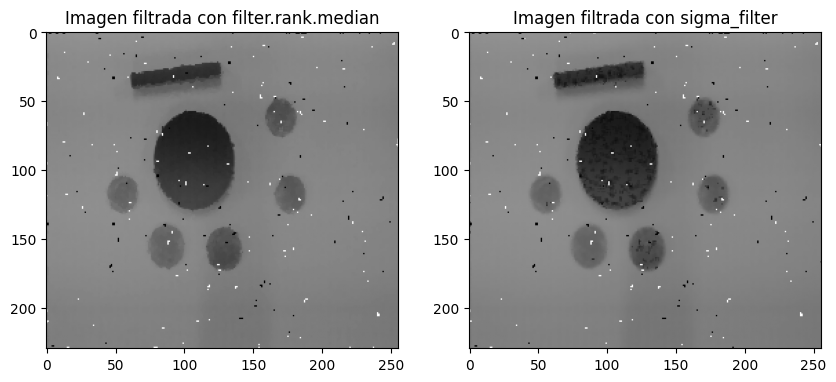

In [26]:
from skimage.filters.rank import median
import numpy as np

imagen_prep = (noised_image_morpho * 255).astype(np.uint8)

image_morpho_filtered_median = median(imagen_prep, footprint=np.ones((3,3)))

fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(image_morpho_filtered_median, cmap='gray')
ax[0].set_title('Imagen filtrada con filter.rank.median')
ax[1].imshow(image_morpho_filtered_sigma, cmap='gray')
ax[1].set_title('Imagen filtrada con sigma_filter')
plt.show()

El filtro de mediana es más efectivo para eliminar el ruido de sal y pimienta. Ya mencionamos que el filtro promedio empeora la calidad de la imagen y el sigma crea aberraciones en la imagen. El filtro de la mediana logra eliminar el ruido casi por completo. A diferencia del promedio, el filtro de mediana posee una naturaleza no lineal que ordena los píxeles de la vecindad para seleccionar únicamente el valor central. Esto permite la eliminación de valores extremos, ya que los puntos de ruido sal y pimienta (0 o 255) quedan siempre en los extremos de la lista ordenada y son descartados, siendo reemplazados por un valor real del fondo. Esto demuestra su superioridad sobre el filtro Sigma, el cual fallaba al recurrir a un promedio global todavía contaminado por el ruido cuando no encontraba vecinos similares, mientras que la mediana simplemente ignora esos picos de intensidad.

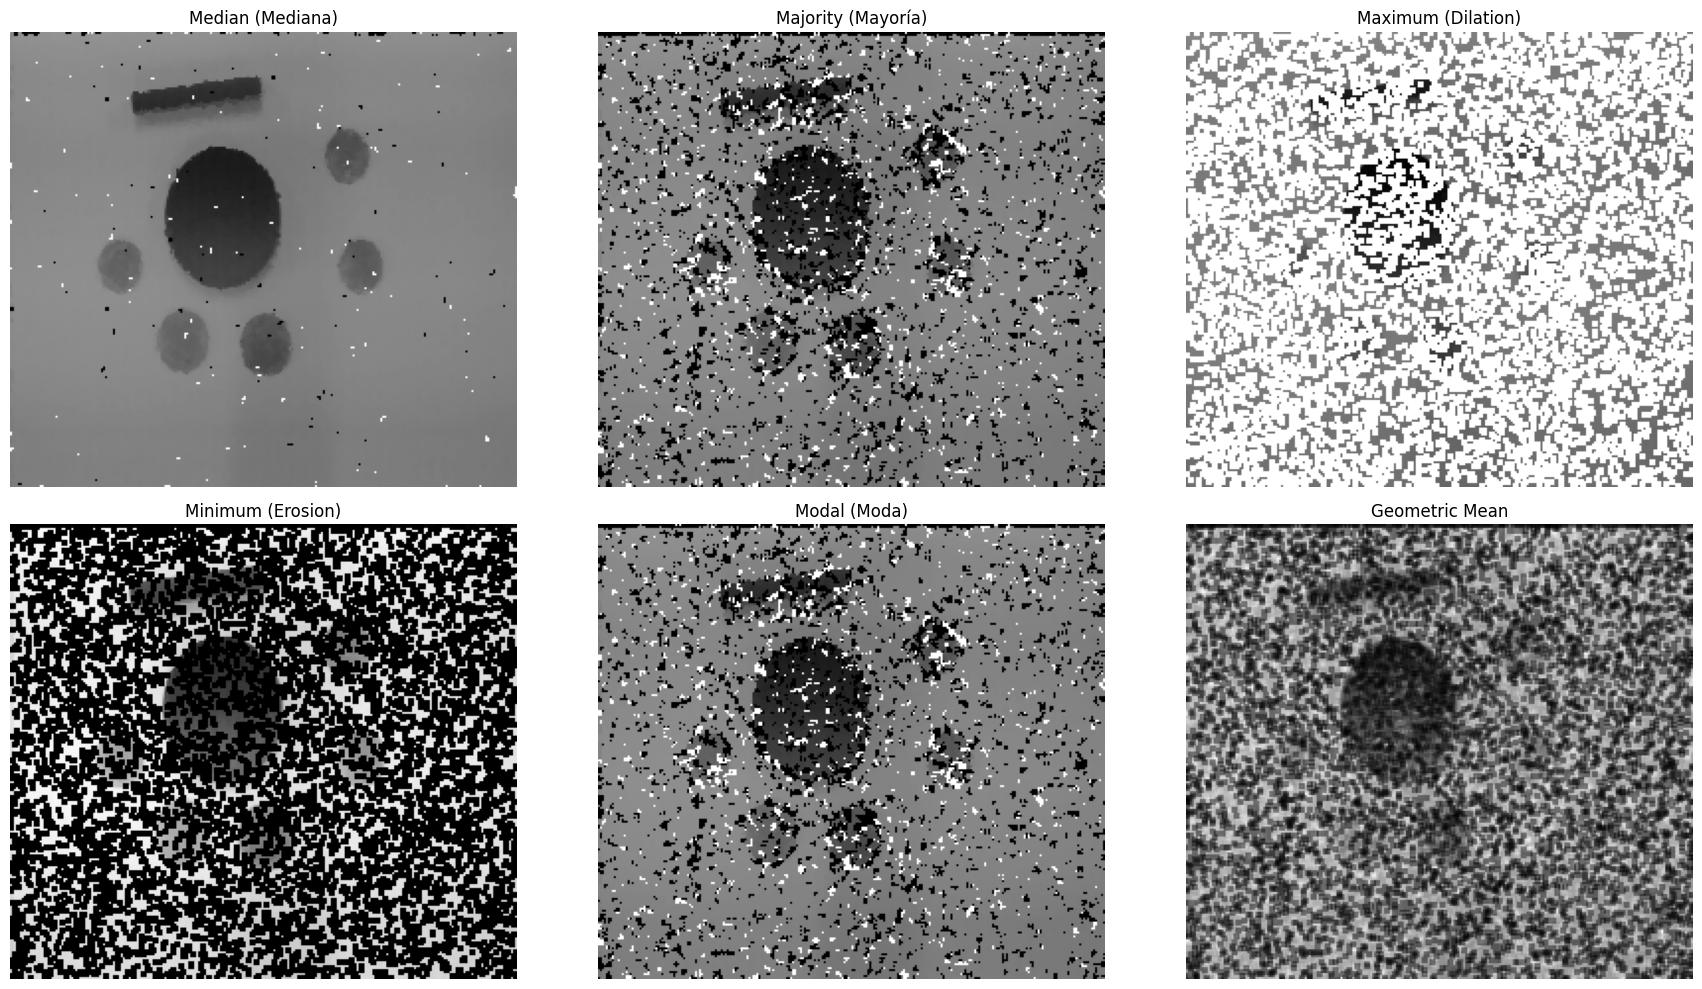

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters.rank import median, majority, maximum, minimum, modal, geometric_mean
from skimage.morphology import square

fp = np.ones((3,3))

# 2. Aplicación de los filtros solicitados
img_median = median(imagen_prep, footprint=fp)
img_majority = majority(imagen_prep, footprint=fp)
img_maximum = maximum(imagen_prep, footprint=fp)
img_minimum = minimum(imagen_prep, footprint=fp)
img_modal = modal(imagen_prep, footprint=fp)
img_geometric = geometric_mean(imagen_prep, footprint=fp)

# 3. Plot de todos los resultados
filtros = [
    (img_median, 'Median (Mediana)'),
    (img_majority, 'Majority (Mayoría)'),
    (img_maximum, 'Maximum (Dilation)'),
    (img_minimum, 'Minimum (Erosion)'),
    (img_modal, 'Modal (Moda)'),
    (img_geometric, 'Geometric Mean')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, (img, titulo) in enumerate(filtros):
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(titulo)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Aplicamos los filtros sugeridos en el enunciado del taller. Los resultados los podemos ver y comparar en la imagen anterior. Para cada filtro, podemos ver lo siguiente:

- **Median (Mediana)**: Devuelve la mediana local de la vecindad. Es el mejor para eliminar ruido de sal y pimienta simultáneamente sin destruir los bordes.

- **Majority (Mayoría)**: Asigna a cada píxel el valor más común dentro de su vecindad. Sirve para rellenar huecos accidentales dentro de una mancha de color, haciendo que toda la región recupere el mismo tono.

- **Maximum (Máximo)**: Devuelve el valor máximo local de la imagen. Es excelente para eliminar el ruido pimienta (puntos negros), pero empeora el ruido sal (puntos blancos).

- **Minimum (Mínimo)**: Devuelve el valor mínimo local de la imagen. Es perfecto para eliminar el ruido sal, aunque oscurece la imagen y empeora el ruido pimienta.

- **Modal (Moda)**: Devuelve la moda local, es decir, el valor que aparece con más frecuencia en el histograma de la vecindad. Es útil para suavizar texturas manteniendo los valores de color predominantes.

- **Geometric Mean (Media Geométrica)**: Devuelve la media geométrica local de la vecindad. Es buena para reducir ruido gaussiano, pero es muy sensible a valores oscuros, ya que un solo píxel en 0 (negro) hará que todo el resultado sea 0.

## Repita las operaciones 3 a 6, pero con un ruido uniforme de amplitud 30.